<a href="https://colab.research.google.com/github/CompModNervSystem/CompModNervSys-BioElectroStatics/blob/main/CompModNervSys_exercise2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BIOL 74.03 (SP23): Computational Modeling of the Nervous System 
## Exercise 2: Calculating and visualizing bioelectric fields in Python

### Exercise goals

1) Gain intuition for electric field and voltage in the context of point charges
2) Learn how to use NumPy to do basic calculations on vectors and arrays
3) Learn how to use matplotlib/plotly to visualize 1, 2, and 3D functions

Work through the code below, running each cell, adding code where required, and making sure you understand the output. When you see questions with ***Q:*** preceding them, write your responses in text cells. 

In [1]:
!git clone https://github.com/CompModNervSystem/CompModNervSys-BioElectroStatics.git

Cloning into 'CompModNervSys-BioElectroStatics'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 12 (delta 1), reused 9 (delta 1), pack-reused 0
Unpacking objects: 100% (12/12), 503.10 KiB | 1.64 MiB/s, done.



# Visualizing the electric field for a point charge

In this exercise, we'll be calculating and visualizing the fields generated by charges. To do this, we'll use two handy python libraries or "packages", NumPy (`numpy`) and `matplotlib`.

Start by importing these packages

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

You'll notice for matplotlib, we just imported a subset of the full package containing the plotting functions. 

Now to use any function within the numpy library, we can use the `np` namespace, and to use plotting functions within `matplotlib.pyplot`, we can use `plt`, which you'll see in a moment. 

If you've never used NumPy, start out by reading through the first three sections of the Introduction to Numpy from the Python Data Science Handbook [here](https://jakevdp.github.io/PythonDataScienceHandbook/02.00-introduction-to-numpy.html). I would recommend clicking the "Open in Colab" button and modifying code in the code section to make sure you understand what's being done. Another good introduction for beginners can be found at the Numpy website, [here](https://numpy.org/doc/stable/user/absolute_beginners.html).

Before moving on, you should be familiar with what numpy arrays are, how to define and inspect the size/shape of 1 and 2D arrays, and the basics of indexing arrays.

Similarly, if you've never used matplotlib, check out the sections on matplotlib [here](https://jakevdp.github.io/PythonDataScienceHandbook/04.00-introduction-to-matplotlib.html) 



Let's start by visualizing the electric field generated by a point charge. Below is some code plotting the location of this point charge, which we'll refer to as our "source" charge, and an example location for a test charge, with some annotations to help us get started. Feel free to change the location of the source or test charge and replot (note, the annotations may not look as pretty depending on where you move it).

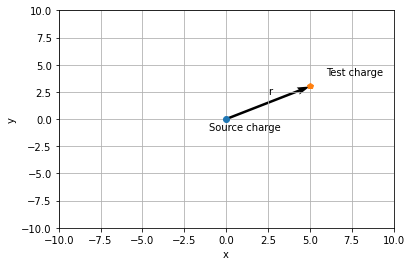

In [ ]:
x0 = 0 # x coordinate of source charge (meters, m)
y0 = 0 # y coordinate of source charge (m)
x_test = 5 # x coordinate of test charge (m)
y_test = 3 # y coordinate of test charge (m)
r_x = x_test - x0 # x component of displacement vector to test charge
r_y = y_test - y0 # y component of displacement vector to test charge
fig = plt.figure()
ax = plt.axes()
ax.plot(x0,y0,marker='o'); # plot source charge
ax.text(x0-1,y0-1,'Source charge')
ax.plot(x_test,y_test,marker='p'); # plot example test charge
ax.text(x_test+1,y_test+1,'Test charge')
ax.quiver(x0,y0,r_x,r_y,color='k',
          angles='xy',scale_units='xy',scale=1) # plot a vector from the source to test charge, represent actual distance
ax.text(x0 + 0.5*r_x,y0 + 0.75*r_y,'r')          
ax.set_xlim([-10,10]); ax.set_ylim([-10,10]);
ax.set_xlabel('x'); ax.set_ylabel('y');
ax.grid()

Our goal is to calculate and visualize the electric field that would be experienced by a test charge anywhere in space.

The equation for the electric field generated by a point charge is given by $\vec{E} = \frac{kQ}{r^{2}}\hat{r}$. 

Recall, $k$ is the universal Coulomb constant ($k = 8.99 \times 10^9 \frac{Nm^{2}}{C^{2}}$), $Q$ is the magnitude of our source charge, $r$ is the distance from the test charge to the source charge, and $\hat{r}$ is the unit vector from the source charge to test charge. 

$\hat{r}$ will depend on the location of the source and test charge, and is given by:

$\hat{r} = \frac{\vec{r}}{r^{2}}$, where

$\vec{r} = (x - x_{0}) \hat{x} + (y - y_{0}) \hat{y}$

$r = \sqrt{(x-x_{0})^2 + (y - y_{0})^2}$.

Putting this together, $\vec{E}$ is given by,

$\vec{E} = \frac{kQ}{r^{2}} \frac{\vec{r}}{r} = \frac{kQ}{r^{3}}\vec{r}=\frac{kQ}{r^{3}}[ (x - x_{0})\hat{x} + (y - y_{0}) \hat{y}]$


We can separate this vector field into its two components (in 2D), $E_{x}$ and $E_{y}$:

$E_{x} = \frac{kQ}{r^{3}}(x - x_{0})\hat{x}$

$E_{y} = \frac{kQ}{r^{3}}(y - y_{0})\hat{y}$

Now, let's try calculating these components over a grid of test charge positions with numpy arrays. We'll start by creating a 2D grid of points using `np.linspace` and `np.meshgrid`.


In [ ]:
N = 21 # number of grid points in x and y direction
x = np.linspace(-10,10,N) # x coordinates (m)
y = np.linspace(-10,10,N) # y coordinates (m)
X, Y = np.meshgrid(x,y) # make 2D grid of x coordinates and y coordinates 

Take a moment to inspect these grids to get some intuition for how they're defined. What happens when you change the row index for the `X` array (e.g., `X[0,0]` vs. `X[1,0]` or column index for the `Y` array (e.g., `Y[0,0]` vs. `Y[0,1]`)?

In [ ]:
# Test out indexing X and Y here

Now, let's calculate $E_{x}$ and $E_{y}$ at these grid points for a unit source charge

In [ ]:
k = 8.99e9 # Coulomb's constant (N m^2 / C^2)
Q = 1 # source charge (C)
r = np.sqrt((X - x0)**2 + (Y-y0)**2) # distance from each position to source charge
Ex = k*Q*(X - x0)/r**3  
Ey = k*Q*(Y - y0)/r**3 


<ipython-input-5-94ccb346e9ae>:4: RuntimeWarning: invalid value encountered in true_divide
  Ex = k*Q*(X - x0)/r**3
<ipython-input-5-94ccb346e9ae>:5: RuntimeWarning: invalid value encountered in true_divide
  Ey = k*Q*(Y - y0)/r**3


***Q1***: What dimensions do you expect `r` to be? What are the units of $E_{x}$ and $E_{y}$?





Now let's plot using `np.quiver`

In [ ]:
Emag = np.hypot(Ex,Ey) # magnitude of E-field at each location

fig = plt.figure()
ax = plt.axes()
q = ax.quiver(X,Y,Ex,Ey,Emag)
ax.set_xlabel('x'); ax.set_ylabel('y');
cbar = plt.colorbar(q)
cbar.ax.set_ylabel('|E|')
ax.axis('equal') # make x and y axis scaling equal

***Q2***: Does this plot make sense? What's going on at `(0,0)`? 





Now, if we want to move the source charge and replot, rather than rewriting all the code above, define a function to calculate the E-field given the charge location, magnitude, and test charge coordinates (`calcEfield`) and a function to plot the vector field (`plotEfieldVecs`) given. To make things easier to interpret, plot the vectors with unit length and set their color to be the magnitude normalized to the global max.

In [ ]:
def calcEfield(x0,y0,X,Y,Q=1):
  k = 8.99e9 # Coulomb's constant  
  r = np.sqrt((X - x0)**2 + (Y-y0)**2) # distance from each position to source charge
  Ex = k*Q*(X - x0)/r**3  
  Ey = k*Q*(Y - y0)/r**3   
  return Ex, Ey

def plotEfieldVecs(X,Y,Ex,Ey):
  fig = plt.figure()
  ax = plt.axes()
  Emag = np.hypot(Ex,Ey) # magnitude of E-field at each location
  Emag_norm = Emag/np.nanmax(Emag)  
  q = ax.quiver(X,Y,Ex/Emag,Ey/Emag,Emag_norm)
  ax.set_xlabel('x'); ax.set_ylabel('y');
  cbar = plt.colorbar(q)
  cbar.ax.set_ylabel('|E|')  
  return fig, ax

Now, use your functions to plot the E-field for a source charge located at `(1.3,2.4)`. Generate plots for both a positive and negative source charge.

# Adding more point charges

So far, the plots are kinda boring. Since we have only one source charge, we just get a radial field centered at the source charge location. What happens if we have a bunch of point charges distributed in space? Modify your calcEfield function to take as input a vector of source charge x coordinates and a vector of y coordinates, instead of a single pair of x and y coordinates, and output the total E-field x and y components ($E_{x}$ and $E_{y}$).

In [ ]:
def calcEfield(x0,y0,X,Y,Q):
  k = 8.99e9 # Coulomb's constant  
  # Your code goes here  
  return Ex, Ey

Now use your revised `calcEfield` function and `plotEfieldVecs` to plot the E-field produced by source charges at `(-5,0)` and `(5,0)`, both with $Q=+1$

In [ ]:
x0 = np.array([-5,5])
y0 = np.array([0,0,2,-4])
Q = np.array([1,1])
Ex, Ey = calcEfield(x0,y0,X,Y,Q);
plotEfieldVecs(X,Y,Ex,Ey);


***Q3***: What happens when you make one charge negative at `x=0`? What if the charges are unequal?  

For fun, let's use your function to plot the E-field distribution for 5 charges with random positions (within the bounds of our `X` and `Y` grid) and random charges from $(-1,1)$. Hint: Look up the `np.random.uniform` function

In [ ]:
Ncharges = # Your code goes here
x0 = #
y0 = #
Q = #

Ex, Ey = calcEfield(x0,y0,X,Y,Q);
plotEfieldVecs(X,Y,Ex,Ey);

Visualizing the vector field is useful to understand the direction and magnitude of the field at each location, but in some cases, we'd just like to know the magnitude. We can visualize this using a 3D surface plot. To do this in an interactive plot, let's turn to a more advanced plotting package called [plotly](https://plotly.com/python/). Luckily, plotly is already installed in the default google colab python environment. We'll wrap this in a function so we can reuse it later. Also, for these plots, it'll help to have a more densely sampled grid. 

In [ ]:
import plotly.graph_objects as go

N = 101 # number of grid points in x and y direction
x = np.linspace(-10,10,N) # x coordinates (m)
y = np.linspace(-10,10,N) # y coordinates (m)
X, Y = np.meshgrid(x,y) # make 2D grid of x coordinates and y coordinates 

Ex, Ey = calcEfield(x0,y0,X,Y,Q); # recalculate on new grid
Emag = np.hypot(Ex,Ey)
Emag_norm = Emag/Emag.max() # normalize to get a sense of relative values

def plotMag3D(X,Y,mag):
  fig = go.Figure(go.Surface(x=X,y=Y,z=mag))  
  fig.update_layout(scene_aspectmode='cube')  
  fig.show()

plotMag3D(X,Y,Emag_norm)

ModuleNotFoundError: No module named 'plotly'

Another way to visualize this distribution is as a 2D heatmap, which we can do using another function in the `plotly` library (specifically in the `express` module)

In [ ]:
import plotly.express as px 

def plotMag2D(x,y,mag): # use 1D arrays instead of 2D
  fig = px.imshow(mag,x=y,y=x,labels={'x':'x','y':'y'})    
  return fig

plotMag2D(x,y,np.log10(Emag_norm))

Since the E-field magnitude is so sharply peaked, it can be hard to see how it varies in space. 

***Q4***: Can you think of a way to make variations in the distribution easier to visualize? (hint: transform the E-field magnitude values)

***Q5***: What would the current density distribution look like? Describe how you would you modify your `calcEfield` function to output current density instead. 

# From E-field to voltage

As covered in class, the electric field can also be represented as a potential distribution, or **voltage**. One key difference to note is the electric field is a *vector* field, meaning it has both magnitude and direction at each point in space, while the voltage is a scalar, meaning it is represented by a single value (magnitude) at each point in space. The E-field flows from high to low potentials. 

The voltage for a point charge in free space is given by, $V = \frac{kQ}{r}$. Write a function called `calcV` to calculate the voltage generated by a set of point charges and plot this distribution for the same point charges as above in a surface plot using our `plotMag` function (Tip: start from your `calcEfield` function)


In [ ]:
def calcV(x0,y0,X,Y,Q):
  k = 8.99e9 # Coulomb's constant  
  V = np.zeros(X.shape)  
  for x0i,y0i,Qi in zip(x0,y0,Q):
    r = np.sqrt((X - x0i)**2 + (Y-y0i)**2) # distance from each position to source charge
    V += k*Qi/r
  return V

V = calcV(x0,y0,X,Y,Q)
Vnorm = V/V.max() # normalize to max
plotMag2D(x,y,Vnorm)


To get a bit more intuition, let's visualize the decay of voltage and E-field magnitude with distance in one dimension

One way to do this is extract a 'slice' of voltage values at a single x or y value where we placed a point charge. 

Text(0, 0.5, 'V (norm.)')

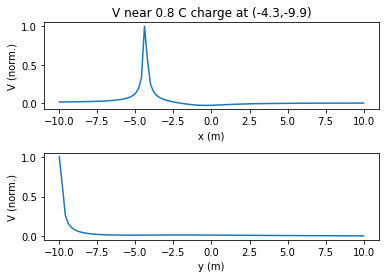

In [ ]:
q_index = 1 # choose which charge to extract slice at 

# Find the row closest to the y coordinate of the charge
row_index = # your code goes here
# Find the column closest to the x coordinate of the charge
col_index = # your code goes here

fig = plt.figure()

ax = fig.add_subplot(211)
# ax.plot(x,V[row_index,:]/np.max(np.abs(V[row_index,:])))
ax.plot(x,Vnorm[row_index,:])
plt.xlabel('x (m)')
ax.set_xlabel('x (m)'); ax.set_ylabel('V (norm.)')
ax.set_title('V near {:.1f} C charge at ({:.1f},{:.1f})'.format(Q[q_index],x0[q_index],y0[q_index]))
fig.subplots_adjust(hspace=0.5) # make space between subplots so x label is visible

ax2 = fig.add_subplot(212)
# ax2.plot(y,V[:,row_index]/np.max(np.abs(V[:,row_index])))
ax2.plot(y,Vnorm[:,col_index])
ax2.set_xlabel('y (m)'); ax2.set_ylabel('V (norm.)')

Do these plots look as you'd expect given the location of the point charges?

# Review of Basic Circuits

Now that we've visualized fields and potential distributions for abstract point charges in space, let's turn to the more idealized world of circuits. Here, it's easier to deal with things in terms of voltages (potential differences) and currents. 

